In [ ]:
import pandas as pd

# Datos del preprocesado
adj_close = pd.read_csv(
    "../Datos_csv/adj_close.csv",
    index_col=0,
    parse_dates=True
)

volume = pd.read_csv(
    "../Datos_csv/volume.csv",
    index_col=0,
    parse_dates=True
)

La metodología se ilustra con SPY como activo representativo. Se trabaja con retornos logarítmicos como variable principal.

In [2]:
import numpy as np
# Retornos
ret_simple = adj_close.pct_change()
ret_log = np.log(adj_close)
ret_log_diff = np.log(adj_close).diff() #diferencia con el dia anterior
dollar_vol = adj_close * volume


In [3]:
import matplotlib.pyplot as plt

# Elegimos un ETF para el estudio (ejemplo: SPY)
etf = "SPY"
#etf="AGG"
# etf="AGG"
serie_adj_close = adj_close[etf].dropna()
serie_ret_simple = ret_simple[etf].dropna()
serie_ret_log = ret_log[etf].dropna()
serie_ret_log_diff = ret_log_diff[etf].dropna()
serie_dollar_vol = dollar_vol[etf].dropna()
serie_volume = volume[etf].dropna()

# print("ETF seleccionado:", etf)
# display(serie_ret_log.head())



Se analiza la estacionariedad de distintas transformaciones de la serie con el objetivo de identificar la representación más adecuada para la modelización temporal.

In [ ]:
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
import warnings
warnings.filterwarnings("ignore", category=InterpolationWarning)

def tests_estacionariedad(serie):
    x = np.asarray(serie, float)
    x = x[~np.isnan(x)]
    # ADF (H0: raíz unitaria / no estacionaria)
    adf_stat, adf_p, adf_lags, adf_n, adf_crit, adf_icbest = adfuller(x, autolag='AIC')
    
    # KPSS (H0: estacionaria)
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(x, regression='c', nlags='auto' )
    if kpss_p <= 0.01 and adf_p>0.01:   # rechazamos KPSS, pero no ADF
        s = "no estacionario"
    elif kpss_p > 0.01 and adf_p<=0.01: # rechazamos ADF, pero no KPSS 
        s = "estacionario"
    elif kpss_p > 0.01 and adf_p > 0.01:
        s = "no concluyente"
    else:
        s = "resultados inconsistentes"
    return s

In [ ]:
import pandas as pd

series_a_testear = {
    "Adj_close": serie_adj_close,
    "log(Adj_close)": serie_ret_log,            
    "retorno_simple": serie_ret_simple,
    "retorno_logaritmico": serie_ret_log_diff,
    "dollar_volume": serie_dollar_vol,
    "volume": serie_volume
}

# Ejecutar tests y guardar resultados
resultados = []
for nombre, s in series_a_testear.items():
    estado = tests_estacionariedad(s)
    resultados.append({
        "ETF": etf,
        "Serie": nombre,
        "N_obs": len(s),
        "Inicio": s.index.min().date() if hasattr(s.index, "min") else None,
        "Fin": s.index.max().date() if hasattr(s.index, "max") else None,
        "Conclusión": estado
    })

res_df = pd.DataFrame(resultados)
display(res_df)

Los retornos son estacionarios; precio y log(precio) no. Se trabaja con retornos logarítmicos porque son directamente interpretables y compatibles con la optimización de carteras posterior.

In [6]:
from pandas.tseries.offsets import DateOffset

end_date = serie_ret_log_diff.index.max()
cutoff = end_date - DateOffset(months=3)

train = serie_ret_log_diff.loc[:cutoff]
test  = serie_ret_log_diff.loc[cutoff + pd.Timedelta(days=1):]  # para que no se pise el día cutoff

print("Cutoff:", cutoff.date())
print("Train:", train.index.min().date(), "->", train.index.max().date(), "| n =", len(train))
print("Test :", test.index.min().date(),  "->", test.index.max().date(),  "| n =", len(test))

Cutoff: 2025-11-02
Train: 2021-01-05 -> 2025-10-31 | n = 1213
Test : 2025-11-03 -> 2026-02-02 | n = 62


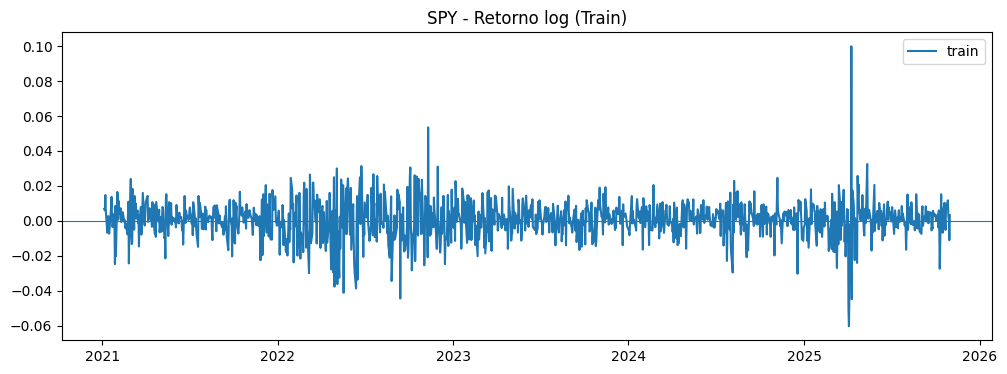

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(train, label="train")
plt.axhline(0, linewidth=0.8)
plt.title("SPY - Retorno log (Train)")
plt.legend()
plt.show()


Autocorrelograma simple (ACF)

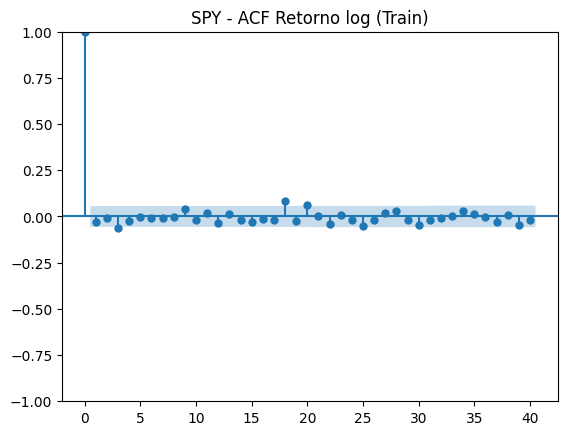

In [8]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(train.dropna(), lags=40)

plt.title("SPY - ACF Retorno log (Train)")
plt.show()

La autocorrelación converge rápidamente a cero, lo que indica que la serie apenas depende de valores pasados. No se observan patrones de tendencia ni estacionalidad, y el comportamiento de la serie parece mayoritariamente aleatorio, salvo una ligera dependencia inicial.

- q = 0: no hay retardos significativos consecutivos (el primero es siempre la autocorrelación consigo mismo)
- Q = 0: no se observa estacionalidad clara, aunque hay una leve repetición hacia los 20-23 días hábiles

Autocorrelograma parcial (PACF)

Mide la dependencia directa entre el valor de hoy y el de hace k días, sin el efecto de los días intermedios.

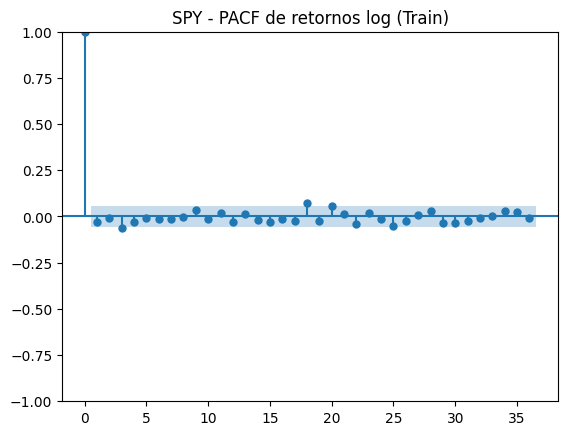

In [9]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plot_pacf(train, lags=36, method="ywm")
plt.title("SPY - PACF de retornos log (Train)")
plt.show()


La PACF confirma que la serie apenas depende de valores pasados y no hay estacionalidad.

- p = 0: no hay retardos significativos en la PACF
- P = 0: no se observan repeticiones estacionales claras

## ELECCIÓN DE PARÁMETROS

**Ljung-Box** contrasta si los residuos del modelo tienen autocorrelación. Queremos p_value > 0.05: residuos sin estructura, cercanos a ruido blanco.

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found.", category=UserWarning)
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Combinaciones de p y q a evaluar (d=0 porque ya trabajamos con retornos)
p_values = range(0, 6)
q_values = range(0, 6)
d = 0

resultados = []
y = train

for p in p_values:
    for q in q_values:
        try:
            res = ARIMA(y, order=(p, d, q), trend="n").fit()

            aic = res.aic
            bic = res.bic

            # Ljung-Box sobre los residuos (20 retardos)
            lb = acorr_ljungbox(res.resid.dropna(), lags=[20], return_df=True)
            p_value = lb["lb_pvalue"].iloc[-1]
            stat = lb["lb_stat"].iloc[-1]  # cuanto más pequeño, más cercano a ruido blanco

            resultados.append({
                "p": p, "d": d, "q": q,
                "AIC": aic, "BIC": bic,
                "p_value": p_value,
                "Estadístico": stat
            })

        except Exception as e:
            continue

res_df = pd.DataFrame(resultados).reset_index(drop=True)
display(res_df)

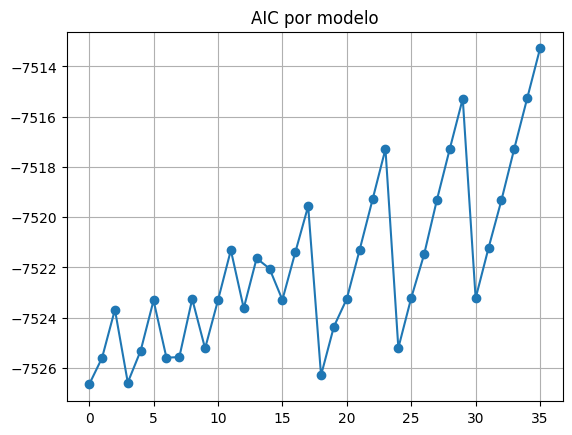

In [11]:
res_df["AIC"].plot(marker="o")
plt.title("AIC por modelo")
plt.grid(True)

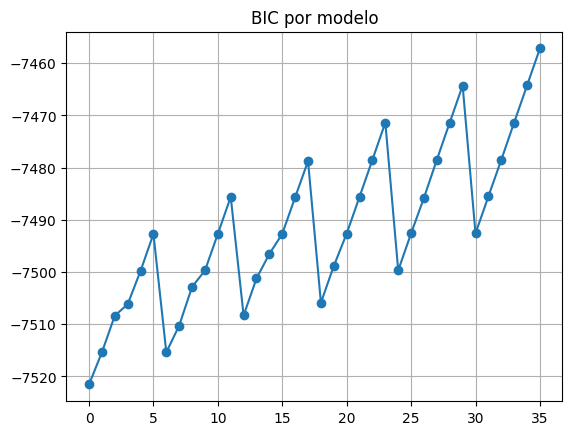

In [12]:
res_df["BIC"].plot(marker="o")
plt.title("BIC por modelo")
plt.grid(True)

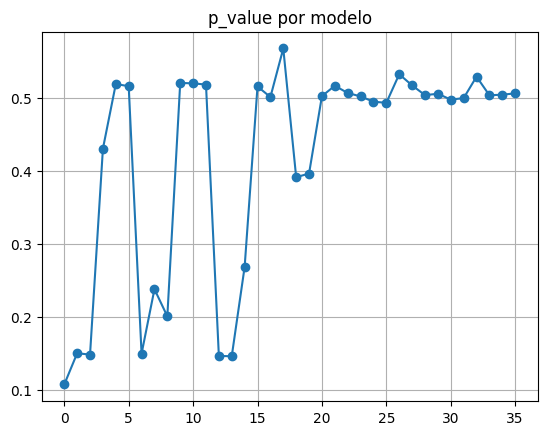

In [13]:
res_df["p_value"].plot(marker="o")
plt.title("p_value por modelo")
plt.grid(True)

In [ ]:
# Filtrar modelos que pasan Ljung-Box (residuos sin autocorrelación)
cand = res_df[res_df["p_value"] > 0.05].copy()

if cand.empty:
    print("Ningún modelo pasa p_value > 0.05.")
    cand = res_df.copy()

# Ordenar por AIC, luego BIC
cand_sorted = cand.sort_values(["AIC","BIC", "p_value"], ascending=[True, True, True])

best = cand_sorted.iloc[0]

print("Mejor modelo seleccionado:")
print(f"ARIMA({int(best['p'])}, {int(best['d'])}, {int(best['q'])})")
print(f"BIC = {best['BIC']:.6f} | AIC = {best['AIC']:.6f} | p_value = {best['p_value']:.4f} | Estadístico = {best['Estadístico']:.4f}")

best

In [15]:
cand_sec = res_df[(res_df["p_value"] > 0.05) & ~((res_df["p"]==0) & (res_df["q"]==0))].copy()

cand_sorted_sec = cand_sec.sort_values(["AIC", "BIC", "p_value"], ascending=True)
best_sec = cand_sorted_sec.iloc[0]

print(best_sec[["p","d","q","AIC","BIC","p_value","Estadístico"]])

p                 0.000000
d                 0.000000
q                 3.000000
AIC           -7526.580838
BIC           -7506.177431
p_value           0.430777
Estadístico      20.439153
Name: 3, dtype: float64


El mejor modelo es ARIMA(0,0,0): la serie se comporta como ruido blanco con media constante. El pasado no aporta información para predecir el siguiente retorno.

- p = 0: sin parte autorregresiva
- d = 0: serie ya estacionaria
- q = 0: sin media móvil

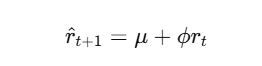

## MODELO ARIMA 

Predicción “walk-forward” / rolling one-step-ahead: cada día se vuelve a ajustar el ARIMA con todo lo visto hasta ese día y se predice solo el siguiente día.

In [16]:
p = int(best_sec["p"])
d = int(best_sec["d"])   
q = int(best_sec["q"])

order = (p, d, q)
print("Usando ARIMA", order)


Usando ARIMA (0, 0, 3)


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore", category=FutureWarning)

y_train = train.copy()
y_test  = test.copy()          
y_test  = y_test.dropna()

pred_1step = pd.Series(index=y_test.index, dtype=float)
params_df = pd.DataFrame(index=y_test.index)

# history crece en cada iteración: empieza con train y se añade el valor real de cada día del test
history = y_train.copy()

# Bucle walk-forward: cada día se reajusta el modelo y se predice un paso adelante
for dt in y_test.index:
    model = ARIMA(history, order=order, trend="n")
    fit = model.fit()
    fc = fit.forecast(steps=1)
    pred_1step.loc[dt] = fc.iloc[0]
    history.loc[dt] = y_test.loc[dt]  # actualizar con el valor real

errores = y_test - pred_1step

out = pd.DataFrame({
    "real": y_test,
    "pred": pred_1step,
    "error": errores
})
display(out)
print("MAE:", errores.abs().mean())
print("RMSE:", np.sqrt((errores**2).mean()))

## Modelo base

Predice el valor del día anterior como si fuera el de mañana (Random Walk).

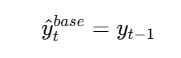

In [ ]:
pred_base = pd.Series(index=y_test.index, dtype=float)
prev_value = y_train.iloc[-1]

for dt in y_test.index:
    pred_base.loc[dt] = prev_value
    prev_value = y_test.loc[dt]

errores_base = y_test - pred_base

out_base = pd.DataFrame({
    "real": y_test,
    "pred_base": pred_base,
    "error_base": errores_base
})

display(out_base)
print("MAE BASE:", errores_base.abs().mean())
print("RMSE BASE:", np.sqrt((errores_base**2).mean()))

## Modelo ceros

Predice siempre cero (retorno nulo). Sirve como referencia mínima.

In [19]:

# !pip install scikit-learn

In [20]:
from sklearn.metrics import root_mean_squared_error

pred_zeros = np.zeros(len(y_test))

In [21]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Modelo ceros

errores_zeros = y_test - pred_zeros
print("MAE ZEROS:", mean_absolute_error(y_test, pred_zeros))
print("RMSE ZEROS:", root_mean_squared_error(y_test, pred_zeros))

MAE ZEROS: 0.0054054026612719705
RMSE ZEROS: 0.00712788925468106


In [22]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import pandas as pd

# Comparación de errores
mae_arima = mean_absolute_error(y_test, pred_1step)
rmse_arima = root_mean_squared_error(y_test, pred_1step)

mae_base = mean_absolute_error(y_test, pred_base)
rmse_base = root_mean_squared_error(y_test, pred_base)

mae_zeros = mean_absolute_error(y_test, pred_zeros)
rmse_zeros = root_mean_squared_error(y_test, pred_zeros)

# Crear tabla con los resultados

results = pd.DataFrame({
    'Modelo': ['ARIMA', 'BASE', 'ZEROS'],
    'MAE': [mae_arima, mae_base, mae_zeros],
    'RMSE': [rmse_arima, rmse_base, rmse_zeros]
})

display(results)

,Modelo,MAE,RMSE
0,ARIMA,0.005441,0.007184
1,BASE,0.007334,0.009837
2,ZEROS,0.005405,0.007128


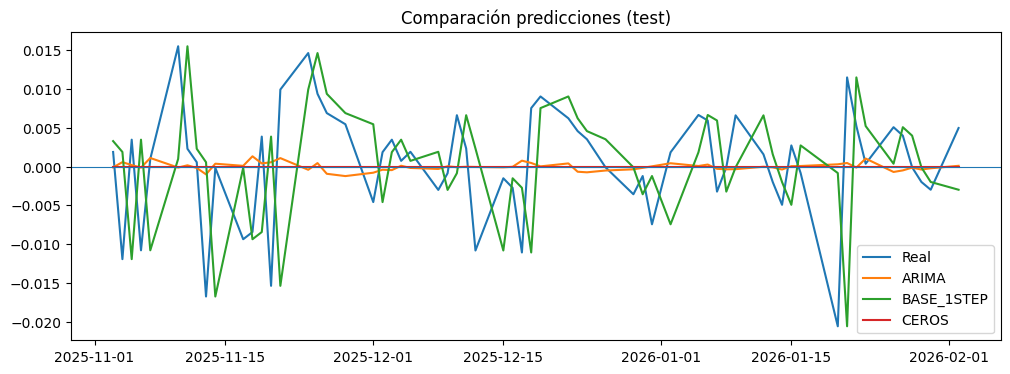

In [23]:
import matplotlib.pyplot as plt
comp = pd.DataFrame({
    "real": y_test,
    "pred_arima": pred_1step,
    "pred_base": pred_base,
    "pred_zeros": pred_zeros
})

plt.figure(figsize=(12,4))
plt.plot(comp["real"], label="Real")
plt.plot(comp["pred_arima"], label="ARIMA")
plt.plot(comp["pred_base"], label="BASE_1STEP")
plt.plot(comp["pred_zeros"], label="CEROS")
plt.axhline(0, linewidth=0.8)
plt.title("Comparación predicciones (test)")
plt.legend()
plt.show()


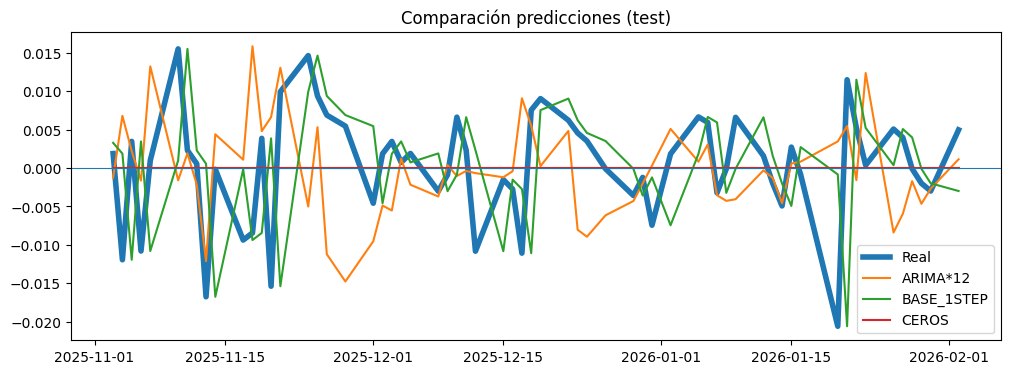

In [24]:
plt.figure(figsize=(12,4))
plt.plot(comp["real"], label="Real",linewidth=4)
plt.plot(comp["pred_arima"]*12, label="ARIMA*12")
plt.plot(comp["pred_base"], label="BASE_1STEP")
plt.plot(comp["pred_zeros"], label="CEROS")
plt.axhline(0, linewidth=0.8)
plt.title("Comparación predicciones (test)")
plt.legend()
plt.show()

In [25]:
# ! pip install arch
from arch import arch_model